In [6]:
import torch
import tensorflow as tf
import jax

In [22]:
import numpy as np
from sklearn.metrics import mean_squared_error
import math

In [8]:
actual = np.array([300000, 500000, 200000, 900000])
predictions = np.array([290000, 550000, 180000, 750000])

In [9]:
mse = mean_squared_error(actual,predictions)
mse

6375000000.0

In [21]:
squared_errors = [(act-pred)**2 for act, pred in zip(actual,predictions)]
sum(squared_errors)/len(actual)

6375000000.0

In [23]:
math.sqrt(mse)

79843.59711335656

In [24]:
from sklearn.metrics import mean_absolute_error

In [25]:
mae = mean_absolute_error(actual,predictions)
mae

57500.0

In [36]:
actual = np.array([300000., 500000., 200000., 900000.])
predictions = np.array([290000., 550000., 180000., 750000.])

learning_rate = 0.2
iterations = 200

print("Initial State:")
print(f"Predictions: {predictions}")
print(f"Initial RMSE: {mean_squared_error(actual, predictions, squared=False):,.2f}\n" + "-"*50)


for i in range(1, iterations+1):
    error_distance = predictions - actual
    gradient  = (2/len(actual)) * error_distance
    predictions = predictions - (learning_rate * gradient)
    rmse = mean_squared_error(actual, predictions, squared=False)
    if i in [1, 2, 5, 10, 20, 50]:
        print(f"Step {i:2d} | Current RMSE: ${rmse:10,.2f} | Current Predictions: {predictions.astype(int)}")
print("-"*50)
print(f"✅ Final Optimized Predictions: {predictions.astype(int)}")
print(f"✅ Final RMSE: {mean_squared_error(actual, predictions, squared=False):.2f}")
        

Initial State:
Predictions: [290000. 550000. 180000. 750000.]
Initial RMSE: 79,843.60
--------------------------------------------------
Step  1 | Current RMSE: $ 71,859.24 | Current Predictions: [291000 545000 182000 765000]
Step  2 | Current RMSE: $ 64,673.31 | Current Predictions: [291900 540500 183800 778500]
Step  5 | Current RMSE: $ 47,146.85 | Current Predictions: [294095 529524 188190 811426]
Step 10 | Current RMSE: $ 27,839.74 | Current Predictions: [296513 517433 193026 847698]
Step 20 | Current RMSE: $  9,707.12 | Current Predictions: [298784 506078 197568 881763]
Step 50 | Current RMSE: $    411.50 | Current Predictions: [299948 500257 199896 899226]
--------------------------------------------------
✅ Final Optimized Predictions: [299999 500000 199999 899999]
✅ Final RMSE: 0.00


Initial State:
Predictions: [290000. 550000. 180000. 750000.]
Initial RMSE: 79,843.60
--------------------------------------------------
Step  1 | Current RMSE: $ 71,859.24 | Current Predictions: [291000 545000 182000 765000]
Step  2 | Current RMSE: $ 64,673.31 | Current Predictions: [291900 540500 183800 778500]
Step  5 | Current RMSE: $ 47,146.85 | Current Predictions: [294095 529524 188190 811426]
Step 10 | Current RMSE: $ 27,839.74 | Current Predictions: [296513 517433 193026 847698]
Step 20 | Current RMSE: $  9,707.12 | Current Predictions: [298784 506078 197568 881763]
Step 50 | Current RMSE: $    411.50 | Current Predictions: [299948 500257 199896 899226]
--------------------------------------------------
✅ Final Optimized Predictions: [299999 500000 199999 899999]
✅ Final RMSE: 0.00



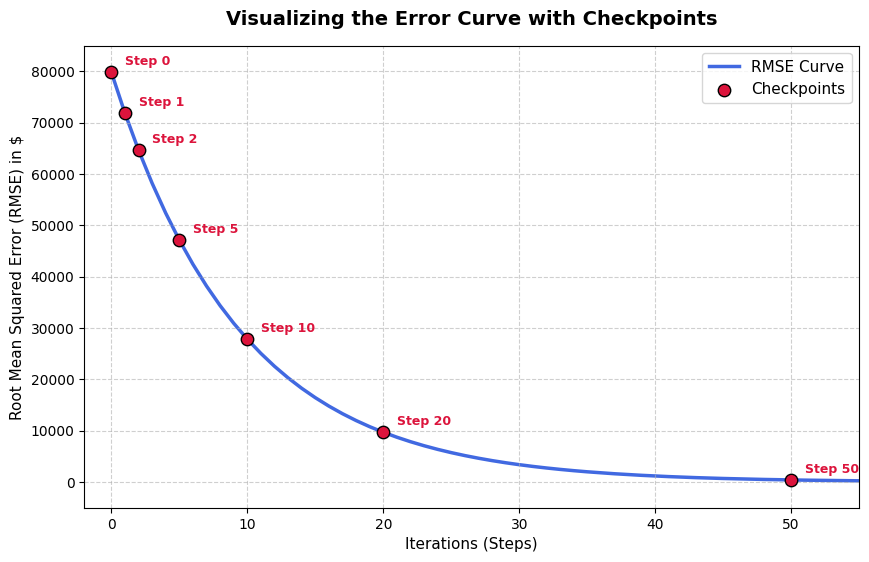

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Define real values and the model's guesses
actual = np.array([300000., 500000., 200000., 900000.])
predictions = np.array([290000., 550000., 180000., 750000.])

# 2. Hyperparameters
learning_rate = 0.2
iterations = 200

# Milestones we want to track and display as checkpoints
checkpoints = [0, 1, 2, 5, 10, 20, 50]

# Track history for plotting
rmse_history = []
initial_rmse = mean_squared_error(actual, predictions, squared=False)
rmse_history.append(initial_rmse)

print("Initial State:")
print(f"Predictions: {predictions}")
print(f"Initial RMSE: {initial_rmse:,.2f}\n" + "-"*50)

# 3. Apply Gradient Descent directly to the predictions
for i in range(1, iterations + 1):
    error_distance = predictions - actual
    gradient = (2 / len(actual)) * error_distance
    predictions = predictions - (learning_rate * gradient)
    
    rmse = mean_squared_error(actual, predictions, squared=False)
    rmse_history.append(rmse)
    
    # Print progress at checkpoints
    if i in checkpoints:
        print(f"Step {i:2d} | Current RMSE: ${rmse:10,.2f} | Current Predictions: {predictions.astype(int)}")

print("-"*50)
print(f"✅ Final Optimized Predictions: {predictions.astype(int)}")
print(f"✅ Final RMSE: {mean_squared_error(actual, predictions, squared=False):.2f}\n")

# 4. Generate the Error Curve Plot
plt.figure(figsize=(10, 6))
plt.plot(rmse_history, color='royalblue', linewidth=2.5, label='RMSE Curve', zorder=1)

# Extract RMSE values for just our checkpoints to plot them
checkpoint_rmse_values = [rmse_history[cp] for cp in checkpoints]

# Add red circle markers at the specific checkpoints
plt.scatter(checkpoints, checkpoint_rmse_values, color='crimson', edgecolor='black', 
            s=80, marker='o', label='Checkpoints', zorder=2)

# Label each individual checkpoint dot with its exact Step number
for cp in checkpoints:
    plt.annotate(f'Step {cp}', 
                 (cp, rmse_history[cp]),
                 textcoords="offset points", 
                 xytext=(10, 5), 
                 ha='left', 
                 fontsize=9, 
                 fontweight='bold',
                 color='crimson')

# Style the chart
plt.title('Visualizing the Error Curve with Checkpoints', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Iterations (Steps)', fontsize=11)
plt.ylabel('Root Mean Squared Error (RMSE) in $', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-2, 55)  # Adjusted slightly left/right to keep labels cleanly in frame
plt.ylim(-5000, 85000)
plt.legend(fontsize=11)